## Not using deep learning algorithm but identify the lane marking by looking at the intensity value

In [46]:
import numpy as np
import pandas as pd
import geopandas as gp
import matplotlib.pyplot as plt

from shapely import wkt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

import utm



+ The intensity of each LIDAR point should contain enough information to recover the lane marking from the flat surface since the lane marking should have a higher intensity compared to the plain asphalt or concrete of the street. 

In [47]:
data=[]
with open('./output_data_26(0027).txt') as f:
    line = f.readline()
    while line:
        d=line.split()
        tmp=[]
        for i in d:
            tmp.append(float(i)) # convert string to float
        data.append(tmp)
        line=f.readline()

In [48]:
a=np.array(data)

### assumption: There's no void space line in txt file.
### intensity: 0~255
pointcloud_df = pd.DataFrame()
pointcloud_df["Latitude"] = a[:,0]
pointcloud_df["Longitude"] = a[:,1]
pointcloud_df["Altitude"] = a[:,2]
i = a[:,3]*255
ii=[]
for x in i:
    ii.append(int(x))
pointcloud_df["Intensity"] = ii

In [49]:
pointcloud_df

,Latitude,Longitude,Altitude,Intensity
0,59.935001,6.171,2.247,0
1,59.452000,6.310,2.231,0
2,59.403999,6.494,2.230,0
3,60.853001,6.847,2.280,0
4,61.116001,7.071,2.290,0
...,...,...,...,...
124239,3.752000,-1.439,-1.758,45
124240,3.761000,-1.430,-1.760,38
124241,3.764000,-1.417,-1.759,114
124242,3.760000,-1.402,-1.755,56


In [53]:
def convert_fuse(pointcloud_df, min_x = 0.0, min_y = 0.0, min_z = 0.0):
#    pointcloud_df["Latitude"] = pd.to_numeric(pointcloud_df["Latitude"])
#    pointcloud_df["Longitude"] = pd.to_numeric(pointcloud_df["Longitude"])
#    pointcloud_df["Altitude"] = pd.to_numeric(pointcloud_df["Altitude"])
#    pointcloud_df["Intensity"] = pd.to_numeric(pointcloud_df["Intensity"])
    
    #Coordinate Conversions
#    pointcloud_df["Easting"] = pointcloud_df.apply(lambda x: utm.from_latlon(x["Latitude"], x["Longitude"])[0], axis = 1)
#    pointcloud_df["Northing"] = pointcloud_df.apply(lambda x: utm.from_latlon(x["Latitude"], x["Longitude"])[1], axis = 1)
 
    pointcloud_df["Easting"] = pointcloud_df["Latitude"]
    pointcloud_df["Northing"] = pointcloud_df["Longitude"]

    if min_x == 0:
        min_x = pointcloud_df["Easting"].min()
    if min_y == 0:
        min_y = pointcloud_df["Northing"].min()   
    if min_z == 0:
        min_z = pointcloud_df["Altitude"].min()    
        
    utm_coords = utm.from_latlon(pointcloud_df.loc[0,"Latitude"], pointcloud_df.loc[0,"Longitude"])

    zone_number = utm_coords[2]
    zone_letter = utm_coords[3]
        
    # negative to positive ? maybe
    pointcloud_df["Easting"] = pointcloud_df["Easting"] - min_x    
    pointcloud_df["Northing"] = pointcloud_df["Northing"] - min_y
    pointcloud_df["Altitude"] = pointcloud_df["Altitude"] - min_z
    
    return pointcloud_df, (min_x, min_y, min_z), (zone_number, zone_letter)

In [54]:
pointcloud_df, (min_x, min_y, min_z), (number, letter) = convert_fuse(pointcloud_df)

In [55]:
pointcloud_df.head()

,Latitude,Longitude,Altitude,Intensity,Easting,Northing
0,59.935001,6.171,27.219,0,139.617001,58.697001
1,59.452000,6.310,27.203,0,139.133999,58.836001
2,59.403999,6.494,27.202,0,139.085999,59.020001
3,60.853001,6.847,27.252,0,140.535000,59.373001
4,61.116001,7.071,27.262,0,140.798000,59.597001


In [56]:
xyzi_df = pointcloud_df[["Easting", "Northing", "Altitude", "Intensity"]]
xyzi_df.to_csv("./pointcloud.xyz", sep=" ", header=False, index=False)
xyzi_df.head()

,Easting,Northing,Altitude,Intensity
0,139.617001,58.697001,27.219,0
1,139.133999,58.836001,27.203,0
2,139.085999,59.020001,27.202,0
3,140.535000,59.373001,27.252,0
4,140.798000,59.597001,27.262,0


## 2. Pointcloud Filtering

1. remove noise (too high or too low intensity)
2. set an adaptive threshold. (lane marking points have a higher intensity value)

In [57]:
def convert_to_shape(row):
    return wkt.loads("POINT (" + str(row["Easting"]) + " " + str(row["Northing"]) +" " + str(row["Altitude"]) + ")")

In [58]:
def filter_by_mean_value(pointcloud_df):

    mean = pointcloud_df["Intensity"].mean()
    std = pointcloud_df["Intensity"].std()

    lanes_df = pointcloud_df[pointcloud_df["Intensity"] > mean + 1 * std]
    lanes_df = lanes_df[lanes_df["Intensity"] < mean +  9 * std ]

    print("MEAN FILTER:")
    print("============")
    print("Intensity - Mean value:      ", mean)
    print("Intensity - Std value:       ", std)
    print("Intensity - Lower bound:     ", mean + 1 * std)
    print("Intensity - Upper bound:     ", mean + 9 * std)
    print("Intensity - Filtered points: ", len(lanes_df))
    print("Intensity - Original points: ", len(pointcloud_df))
    print("Intensity - Reduction to %:  ", len(lanes_df)/len(pointcloud_df))
    
    return lanes_df

In [59]:
lanes_df = xyzi_df.copy()
lanes_df = filter_by_mean_value(lanes_df)
lanes_df[['Easting', 'Northing', 'Altitude', 'Intensity']].to_csv("./filter_mean.xyz", index=False)

MEAN FILTER:
Intensity - Mean value:       69.34163420366376
Intensity - Std value:        42.44114303034119
Intensity - Lower bound:      111.78277723400495
Intensity - Upper bound:      451.3119214767345
Intensity - Filtered points:  18342
Intensity - Original points:  124244
Intensity - Reduction to %:   0.14762885934129616


## 3. Lane Marking Detection

In [60]:
X = lanes_df[["Easting", "Northing", "Altitude"]].values
X = StandardScaler().fit_transform(X)

In [61]:
db = DBSCAN(eps=0.1, min_samples=40).fit(X)
#eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other. (default=0.5)
#min_samplesint: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.(default=5)

labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

In [62]:
lanes_df["Group"] = labels
cluster_df = lanes_df[["Easting", "Northing", "Altitude", "Group"]]
cluster_df = cluster_df[cluster_df["Group"]>=0]
cluster_df.to_csv("./clustering.xyz",index=False)
cluster_df.head()

,Easting,Northing,Altitude,Group
57707,80.105999,38.907001,23.334,0
57711,80.253999,38.936001,23.337,0
57713,80.337999,38.976001,23.342,0
57714,80.379999,38.992001,23.343,0
57715,80.418999,39.041001,23.350,0


In [63]:
print("Final list of labels:       ", labels)
print("Number of Clusters:         ", n_clusters_)
print("Number of Noise points:     ", n_noise_)
print("Number of clustered points: ", len(cluster_df))

Final list of labels:        [-1 -1 -1 ...  7  7  7]
Number of Clusters:          13
Number of Noise points:      14535
Number of clustered points:  3807


In [64]:
print(lanes_df["Easting"].max())
print(lanes_df["Easting"].min())
print(lanes_df["Easting"].mean())
print("---------------------------")
print(lanes_df["Northing"].max())
print(lanes_df["Northing"].min())
print(lanes_df["Northing"].mean())

150.85700225829999
3.789001464799995
79.34749069793165
---------------------------
81.80800056460001
23.2660007477
51.72461094351505


In [67]:
lines = []

for cluster in range(n_clusters_):
    sub_cluster_df = cluster_df[cluster_df["Group"] == cluster]
    points = sub_cluster_df[["Easting","Northing", "Altitude"]].values
    distances = squareform(pdist(points))
    for i in range(0,15):
        max_index = np.argmax(distances)
        i1, i2 = np.unravel_index(max_index, distances.shape)
        distances[i1,i2] = 0.0
    max_dist = np.max(distances)
    max_index = np.argmax(distances)
    i1, i2 = np.unravel_index(max_index, distances.shape)
    p1 = sub_cluster_df.iloc[i1]
    p2 = sub_cluster_df.iloc[i2]
    lines.append(([p1["Easting"], p2["Easting"]],[p1["Northing"], p2["Northing"]], [p1["Altitude"], p2["Altitude"]]))

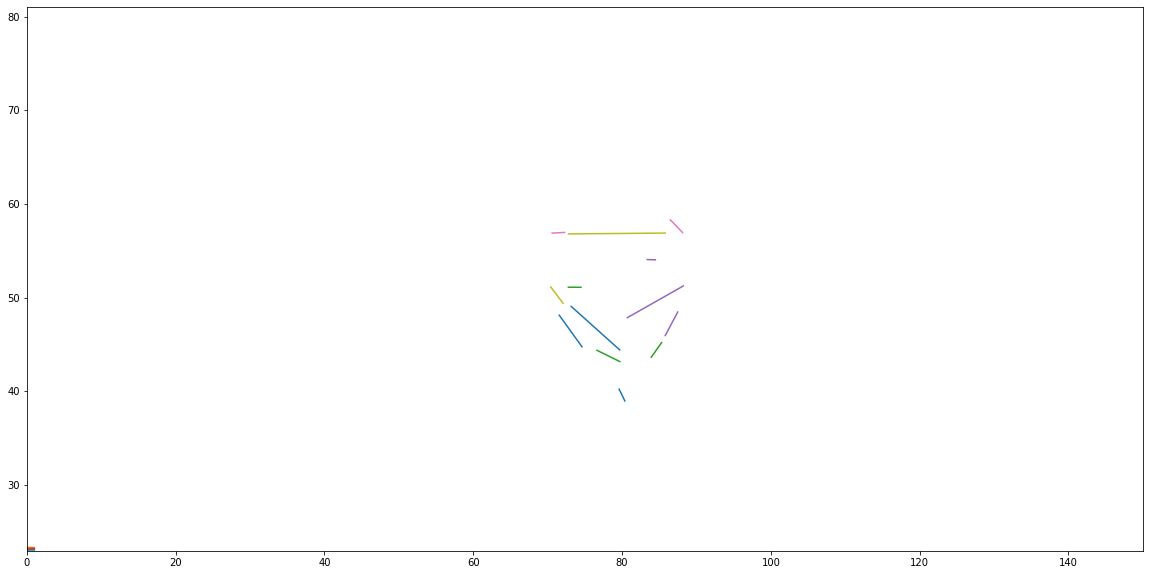

Number of prototype lane markings:  13


In [69]:
plt.figure(figsize=(20,10))
plt.xlim(0,150),plt.ylim(23,81)

for l in lines:
    plt.plot(l[0], l[1], l[2])
    
plt.show()

print("Number of prototype lane markings: ", len(lines))

In [116]:
def create_line(coords):
    return wkt.loads("LINESTRING(" + str(coords[0][0]) + " " +str(coords[1][0]) + ", " + str(coords[0][1]) + " " + str(coords[1][1]) +")")
    
distance_matrix = []

for l1 in range(len(lines)):
    prototype = []
    distances = []
    line1 = create_line(lines[l1])
    for l2 in range(len(lines)):
        line2 = create_line(lines[l2])
        d = line1.distance(line2)
        if d == 0:
            d = 100
        distances.append(d)
        
    distance_matrix.append(distances)

distances = np.array(distance_matrix)

In [117]:
fusions = set()

for row in range(distances.shape[0]):
    for column in range(distances.shape[1]):
        value = distances[row,column]
        if value < 1.0:
            min_index = min(row, column)
            max_index = max(row, column)
            fusions.add((min_index, max_index))
            
fusions = list(fusions)
fusion_clusters = []
finished = []
fusions.sort()

for i in range(len(fusions)):
    new_cluster = list(fusions[i])
    if new_cluster[0] not in finished and new_cluster[1] not in finished:
        for j in range(i+1, len(fusions)):
            f = list(fusions[j])
            if (f[0] in new_cluster or f[1] in new_cluster) and f[0] not in finished:
                new_cluster.extend(f)
        fusion_clusters.append(list(set(new_cluster)))
        finished.extend(list(set(new_cluster)))
        
fused_lines = [item for sublist in fusion_clusters for item in sublist]
for i in range(distances.shape[0]):
    if i not in fused_lines:
        fusion_clusters.append([i])

In [118]:
final_lane_markings = []

for cluster in fusion_clusters:
    if len(cluster) == 1:
        final_lane_markings.append(lines[cluster[0]])
    else:
        points = []
        for segment in cluster:
            l = lines[segment]
            points.append([l[0][0], l[1][0], l[2][0]])
            points.append([l[0][1], l[1][1], l[2][1]])
        points = np.array(points)
        distances = squareform(pdist(points))
        max_dist = np.max(distances)
        max_index = np.argmax(distances)
        i1, i2 = np.unravel_index(max_index, distances.shape)
        
        p1 = points[i1]
        p2 = points[i2]

        final_lane_markings.append(([p1[0], p2[0]],[p1[1], p2[1]], [p1[2], p2[2]]))

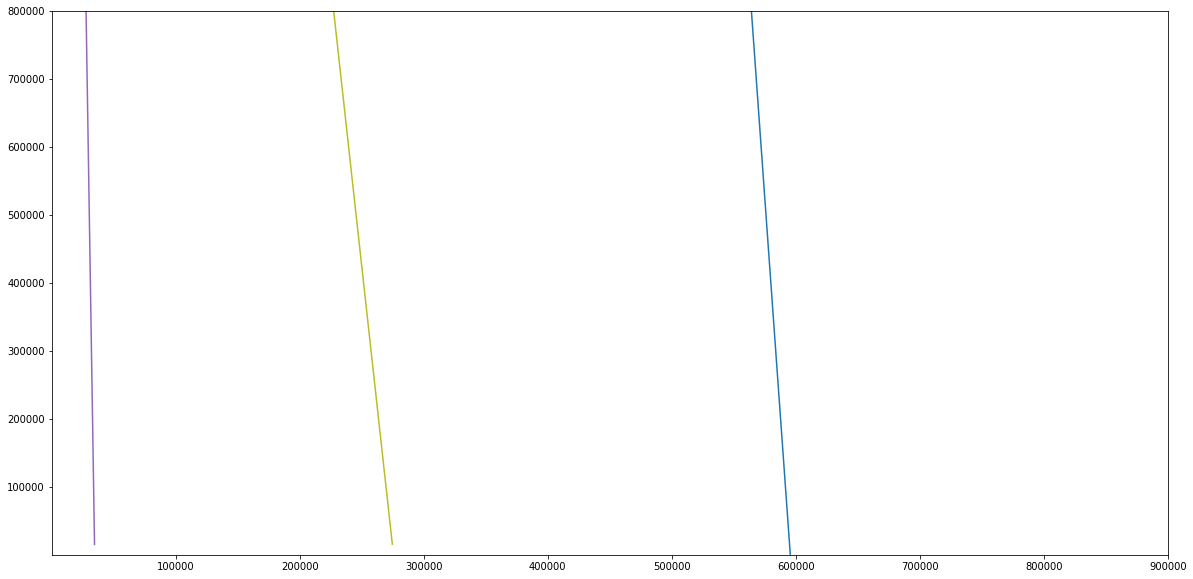

Number of final lane markings:  7


In [119]:
plt.figure(figsize=(20,10))
plt.xlim(100, 900000), plt.ylim(1000,800000) ## 

for l in final_lane_markings:
    plt.plot(l[0], l[1], l[2])
    
plt.show()

print("Number of final lane markings: ", len(final_lane_markings))